In [80]:
import pandas as pd
import matplotlib.pyplot as pl
import seaborn as sns

In [81]:
data = pd.read_csv('loan_approval_nepal_clean.csv')
data.head()

,name,age,monthly_income_npr,credit_score,existing_loans,loan_status
0,Rajesh Shrestha,31,105904,846,0,Approved
1,Maya Gurung,37,50454,341,1,Rejected
2,Bishnu Thapa,26,137009,300,3,Approved
3,Sunita Karki,57,44916,484,2,Rejected
4,Dinesh Rai,56,83911,301,3,Rejected


In [82]:
X = data[['monthly_income_npr','credit_score']]
Y = data['loan_status']

In [83]:
X.head()

,monthly_income_npr,credit_score
0,105904,846
1,50454,341
2,137009,300
3,44916,484
4,83911,301


In [84]:
Y.head()

0    Approved
1    Rejected
2    Approved
3    Rejected
4    Rejected
Name: loan_status, dtype: str

In [85]:
data['loan_status'].value_counts()

loan_status
Approved    25
Rejected    25
Name: count, dtype: int64

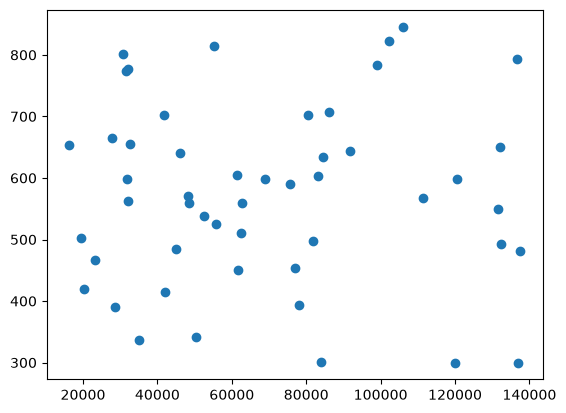

In [86]:
pl.scatter(data['monthly_income_npr'],data['credit_score'])

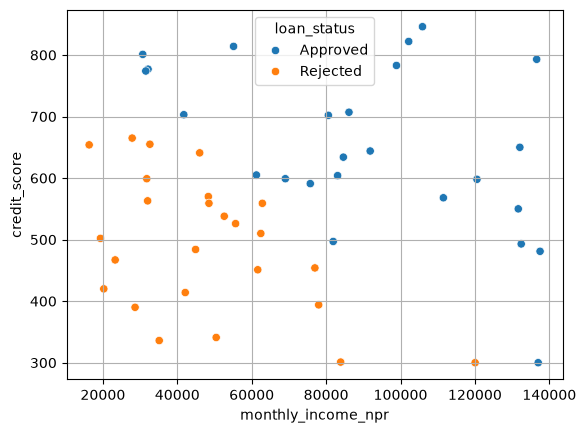

In [87]:
sns.scatterplot(x=data['monthly_income_npr'],y=data['credit_score'],hue=data['loan_status'])
pl.grid()
pl.show()

In [88]:
# loigistic regression
from sklearn.linear_model import LogisticRegression

In [89]:
# ax+by+c=0
# ax+by+c<0 Rejected
# ax+by+c>0 Approved

In [90]:
# Y = Y.map({'Approved':1,'Rejected':0})

In [91]:
model = LogisticRegression()

In [92]:
model.fit(X,Y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [93]:
X.head()

,monthly_income_npr,credit_score
0,105904,846
1,50454,341
2,137009,300
3,44916,484
4,83911,301


In [94]:
model.coef_

array([[-0.00188051, -0.40824018]])

In [95]:
model.intercept_

array([352.96366219])

In [96]:
model.predict([[100023,734]])

C:\Users\Hemraj\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['Approved'], dtype=object)

In [97]:
model.predict([[10023,934]])

C:\Users\Hemraj\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['Approved'], dtype=object)

In [127]:
# multiclass classification problem(Logistic regression)

In [126]:
df = pd.read_csv('loan_approval_nepal_clean_v2.csv')

In [99]:
df.head(8)

,name,age,monthly_income_npr,credit_score,existing_loans,loan_status
0,Purnima Bhandari,28,31049,357,1,Not Approved
1,Laxmi Yadav,55,17082,307,1,Not Approved
2,Bikram Bogati,53,50713,407,1,Not Approved
3,Devi Ghimire,38,25463,478,2,Not Approved
4,Ram Bhandari,30,72059,516,1,Hold
5,Kumar Tamang,43,17847,486,2,Not Approved
6,Sarala Rai,45,38700,447,1,Not Approved
7,Ram Ghimire,23,55229,549,1,Hold


In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   name                70 non-null     str  
 1   age                 70 non-null     int64
 2   monthly_income_npr  70 non-null     int64
 3   credit_score        70 non-null     int64
 4   existing_loans      70 non-null     int64
 5   loan_status         70 non-null     str  
dtypes: int64(4), str(2)
memory usage: 3.4 KB


In [101]:
X = df[['monthly_income_npr', 'credit_score']]
Y = df['loan_status']

In [102]:
X.head()

,monthly_income_npr,credit_score
0,31049,357
1,17082,307
2,50713,407
3,25463,478
4,72059,516


In [103]:
Y.head()

0    Not Approved
1    Not Approved
2    Not Approved
3    Not Approved
4            Hold
Name: loan_status, dtype: str

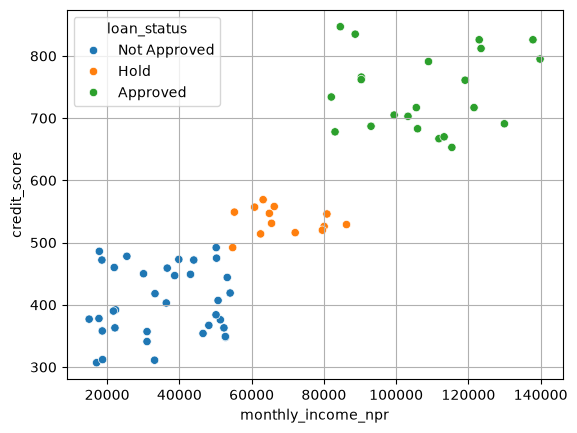

In [104]:
sns.scatterplot(x=df['monthly_income_npr'],y=df['credit_score'],hue=df['loan_status'])
pl.grid()
pl.show()

In [105]:
Y.shape

(70,)

In [114]:
model = LogisticRegression(max_iter=1000)

In [115]:
model.fit(X,Y)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [116]:
model.coef_

array([[ 0.00402642,  0.1460887 ],
       [ 0.0008945 , -0.01543182],
       [-0.00492091, -0.13065725]])

In [117]:
model.intercept_

array([-364.76337084,   -2.08405783,  366.84742867])

In [121]:
model.predict([[23000,321]])

C:\Users\Hemraj\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['Not Approved'], dtype=object)

In [125]:
model.predict([[207040,612]])

C:\Users\Hemraj\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['Approved'], dtype=object)